# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи классификации

## Загрузка данных и понижение размерности

Прежде, чем работать с данными, применим к ним стандартизацию. Отметим, что в ходе EDA к данным была применено MinMax масштабирование, но дополнительная стандартизация существенно влияет на производительность при обучении нейронных сетей.

После этого применим понижение размерности данных при помощи UMAP. С помощью этого алгоритма на основе предыдущих признаков будут построены 3 новых, тем самым понизив признаковое пространство с 5 исходных признаков до 3.

Следующим этапом применим RandomUnder-сэмплирование. Эта стретегия балансировки классов подразумевает удаление экземпляров мажоритарного класса. Тем самым будет произведена балансировка классов и уменьшено общее количество объектов, что благоприятно для обучения нейронных сетей.

In [1]:
import pickle

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from umap import UMAP
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from tensorflow import keras
import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

data = pd.read_csv("datasets/neo.csv", index_col = 0)

X, y = data.drop("hazardous", axis=1), data["hazardous"]


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X.shape

(90836, 5)

In [3]:
y.value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

rus = RandomUnderSampler(sampling_strategy=0.95, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

umap = UMAP(n_components=3, random_state=42)
X_train_res = umap.fit_transform(X_train_res)
X_val = umap.transform(X_val)
X_test = umap.transform(X_test)
X_train = umap.transform(X_train)

C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [5]:
X_train_res.shape

(14516, 3)

In [6]:
y_train_res.value_counts()

hazardous
0    7444
1    7072
Name: count, dtype: int64

Видим, что количество объектов уменьшилось до 21216.

## FCNN (MLP) из библиотеки Scikit-learn

In [7]:
columns = [
    'Classifier', 'Search strategy',
    'Train_F1', 'Train_Accuracy', 'Train_Precision', 'Train_Recall',
    'Test_F1', 'Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver


In [8]:
def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_test, test_pred), 4),
        'Test_F1': round(f1_score(y_test, test_pred), 2),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

Отметим, какие гиперпараметры будут настраиваться в ходе подбора параметров для обучения модели.

*   **hidden_layer_sizes**: Архитектура сети (количество слоев с заданным количеством нейронов).
*   **activation**: Функция активации (`relu`, `tanh`, `logistic`).
*   **solver**: Оптимизатор весов (`adam`, `lbfgs`, `sgd`).
*   **alpha**: Параметр L2-регуляризации для предотвращения переобучения (от 1e-5 до 1e-2).
*   **learning_rate**: Стратегия изменения шага обучения (`constant` или `adaptive`).
*   **learning_rate_init**: Начальная скорость обучения (диапазон от 1e-4 до 1e-2).


In [9]:
solvers = ['adam', 'sgd', 'lbfgs']
best_models_classifier_optuna = {}

for current_solver in solvers:

    def objective(trial):
        params = {
            'hidden_layer_sizes': trial.suggest_categorical(
                'hidden_layer_sizes', [(100,), (50, 50), (100, 50), (100, 100, 100)]
            ),
            'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
            'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),
            'solver': current_solver
        }

        classifier = MLPClassifier(**params, random_state=15, max_iter=50)

        score = cross_val_score(classifier, X_train_res, y_train_res, cv=3, n_jobs=-1, scoring="f1").mean()
        return score

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10)

    print(f"Лучшие параметры для {current_solver}: {study.best_params}")

    final_params = study.best_params.copy()
    final_params['solver'] = current_solver

    final_model = MLPClassifier(**final_params, random_state=15, max_iter=50)
    final_model.fit(X_train_res, y_train_res)

    best_models_classifier_optuna[current_solver] = final_model

    model_name = f"MLPClassifier ({current_solver})"
    input_into_table(model_name, "Optuna", final_model, X_train, y_train, X_test, y_test)
table

[I 2026-05-16 08:55:07,986] A new study created in memory with name: no-name-7825bfc6-d37d-420e-80e2-4bc4b6dc7ea3
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\Ap

Лучшие параметры для adam: {'hidden_layer_sizes': (100, 100, 100), 'activation': 'relu', 'alpha': 3.805283771661539e-05}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-05-16 08:55:33,773] A new study created in memory with name: no-name-13772d15-2f2a-4d40-9c58-8c174a99af99
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186

Лучшие параметры для sgd: {'hidden_layer_sizes': (50, 50), 'activation': 'relu', 'alpha': 1.743097838946472e-05}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
[I 2026-05-16 08:56:06,350] A new study created in memory with name: no-name-0a1e5e48-b3a2-4dbb-ae8f-52832a6518a2
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186228.py:10: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
C:\Users\79585\AppData\Local\Temp\ipykernel_7200\338186

Лучшие параметры для lbfgs: {'hidden_layer_sizes': (100, 100, 100), 'activation': 'tanh', 'alpha': 1.8804757472306858e-05}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs


Заметим, что для всех моделей характерен высокий recall (так, для adam recall = 0.9966, для прочих он не ниже 0.98).

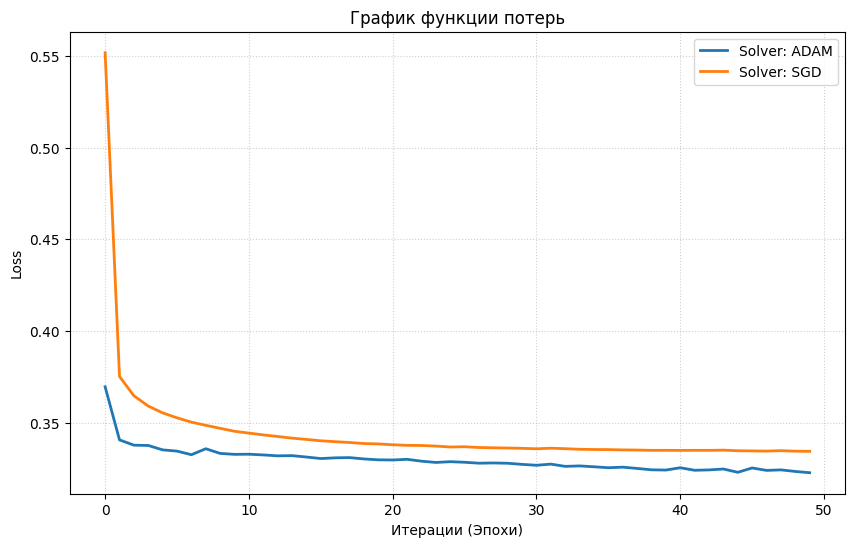

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for solver_name in ['adam', 'sgd']:
    model = best_models_classifier_optuna[solver_name]
    plt.plot(model.loss_curve_, label=f'Solver: {solver_name.upper()}', lw=2)

plt.title('График функции потерь')
plt.xlabel('Итерации (Эпохи)')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Видим, что у оптимизатора Adam ошибка меньше, чем у SGD.

In [11]:
model = best_models_classifier_optuna['adam']
n_layers = len(model.coefs_)

print(f"Количество скрытых слоев: {model.n_layers_ - 2}")
print(f"Архитектура слоев (нейроны):")
for i, weights in enumerate(model.coefs_):
    print(f" Связи между слоем {i} и {i+1}: {weights.shape[0]} -> {weights.shape[1]}")

Количество скрытых слоев: 3
Архитектура слоев (нейроны):
 Связи между слоем 0 и 1: 3 -> 100
 Связи между слоем 1 и 2: 100 -> 100
 Связи между слоем 2 и 3: 100 -> 100
 Связи между слоем 3 и 4: 100 -> 1


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm_train = confusion_matrix(y_train, model.predict(X_train))
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")
    axes[0].grid(False)

    cm_test = confusion_matrix(y_test, model.predict(X_test))
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")
    axes[1].grid(False)

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


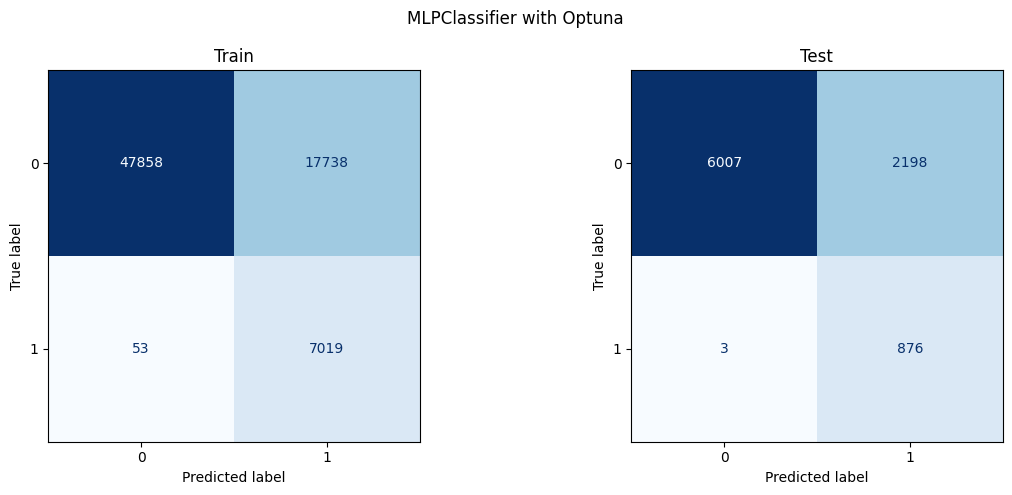

In [13]:
make_graphic(model, "MLPClassifier with Optuna")

In [14]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(3, 100), (100, 100), (100, 100), (100, 1)]


* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 100 нейронов.
* **Третий скрытый слой**: 100 нейронов.
* **Выходной слой**: 1 нейрон.

### RandomizedSearchCV

In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

solvers = ['adam', 'sgd', 'lbfgs']
best_models_classifier_rs = {}

for current_solver in solvers:
    param_dist = {
        'hidden_layer_sizes': [(100,), (50, 50), (100, 50), (100, 100, 100)],
        'activation': ['relu', 'tanh', 'logistic'],
        'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
        'solver': [current_solver]
    }


    mlp = MLPClassifier(max_iter=50, random_state=15)

    rs = RandomizedSearchCV(
        estimator=mlp,
        param_distributions=param_dist,
        n_iter=10,
        n_jobs=-1,
        cv=3,
        scoring="f1",
        verbose=2,
        random_state=15
    )

    rs.fit(X_train_res, y_train_res)

    print(f"Лучшие параметры для {current_solver}: {rs.best_params_}")

    best_models_classifier_rs[current_solver] = rs.best_estimator_

    model_name = f"MLPClassifier ({current_solver})"
    input_into_table(model_name, "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Лучшие параметры для adam: {'solver': 'adam', 'hidden_layer_sizes': (100, 100, 100), 'alpha': 1e-05, 'activation': 'relu'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Лучшие параметры для sgd: {'solver': 'sgd', 'hidden_layer_sizes': (100, 100, 100), 'alpha': 1e-05, 'activation': 'relu'}
Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Лучшие параметры для lbfgs: {'solver': 'lbfgs', 'hidden_layer_sizes': (100, 50), 'alpha': 0.001, 'activation': 'tanh'}


In [16]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs


По f1 результаты RandomSearch практические такие же, как у optuna - лучший R2 = 0.9966 у оптимизатора Adam.

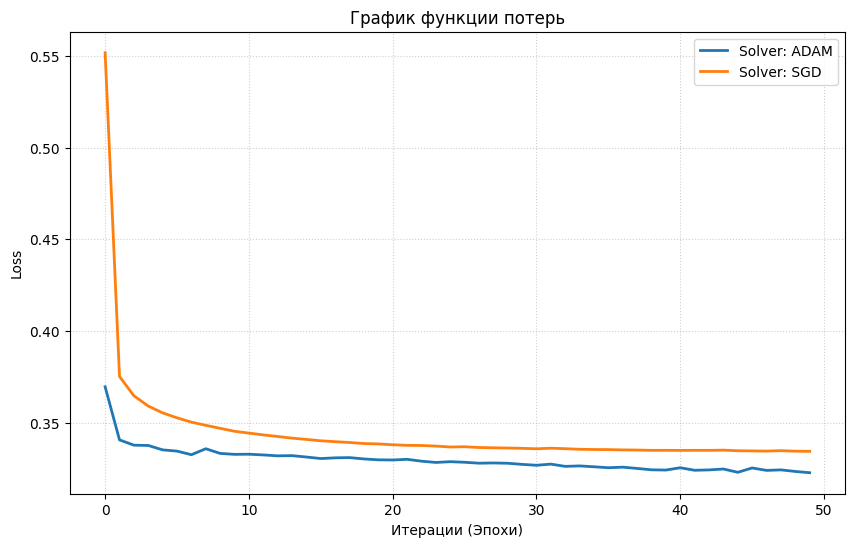

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for solver_name in ['adam', 'sgd']:
    model = best_models_classifier_optuna[solver_name]
    plt.plot(model.loss_curve_, label=f'Solver: {solver_name.upper()}', lw=2)

plt.title('График функции потерь')
plt.xlabel('Итерации (Эпохи)')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Из графика функции потерь видно, что алгоритм Adam сходится лучше.

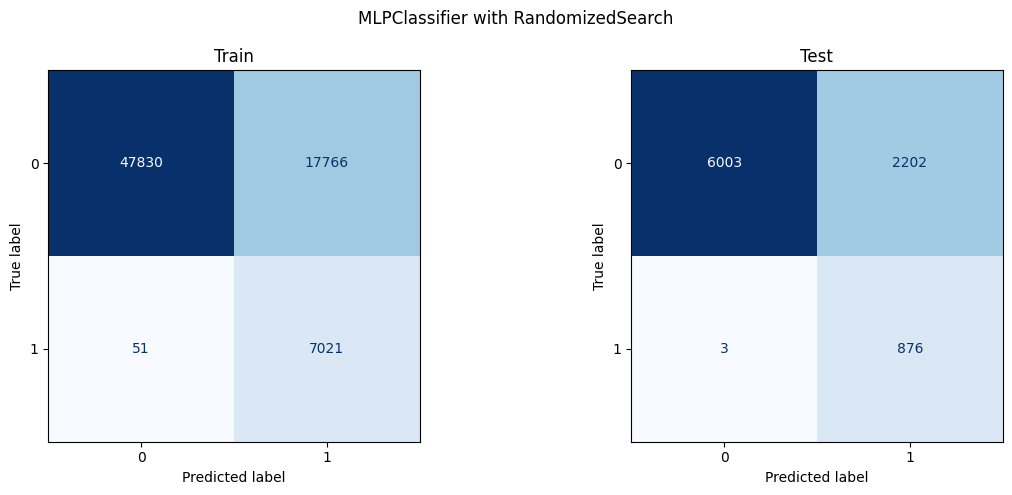

In [18]:
best_rs_model = best_models_classifier_rs['adam']
make_graphic(best_rs_model, "MLPClassifier with RandomizedSearch")

Видим, что минимизурется ошибка второго рода (ложно-отрицательные срабатывания).

In [19]:
print(f"Архитектура сети: {best_rs_model.hidden_layer_sizes}")

print(f"Количество слоев: {best_rs_model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_rs_model.coefs_]}")

Архитектура сети: (100, 100, 100)
Количество слоев: 5
Количество весов (коэффициентов): [(3, 100), (100, 100), (100, 100), (100, 1)]


* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 100 нейронов.
* **Третий скрытый слой**: 100 нейронов.
* **Выходной слой**: 1 нейрон (результат бинарной классификации).

### Hyperport

In [20]:

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

layers = [(100,), (50, 50), (100, 50), (100, 100, 100)]
solvers = ['adam', 'sgd', 'lbfgs']
activations = ['relu', 'tanh', 'logistic']
learning_rates = ['constant', 'adaptive']

best_models_classifier_hyperopt = {}

for current_solver in solvers:
    space = {
        'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
        'activation': hp.choice('activation', activations),
        'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    }


    def objective(params):
        params['solver'] = current_solver
        model = MLPClassifier(**params, max_iter=50, random_state=42)
        score = cross_val_score(model, X_train_res, y_train_res, cv=3, scoring='f1', n_jobs=-1).mean()
        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=15, trials=trials, show_progressbar=False)

    best_params = {
        'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
        'solver': current_solver,
        'activation': activations[best_indices['activation']],
        'alpha': best_indices['alpha']
    }

    print(f"Лучшие параметры для {current_solver}: {best_params}")

    best_model = MLPClassifier(**best_params, max_iter=50, random_state=42).fit(X_train_res, y_train_res)
    best_models_classifier_hyperopt[current_solver] = best_model

    model_name = f"MLPClassifier ({current_solver})"
    input_into_table(model_name, "Hyperopt", best_model, X_train, y_train, X_test, y_test)
table

Лучшие параметры для adam: {'hidden_layer_sizes': (100, 50), 'solver': 'adam', 'activation': 'relu', 'alpha': np.float64(0.00010238567670556634)}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Лучшие параметры для sgd: {'hidden_layer_sizes': (50, 50), 'solver': 'sgd', 'activation': 'relu', 'alpha': np.float64(0.0001798871594811899)}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Лучшие параметры для lbfgs: {'hidden_layer_sizes': (100, 100, 100), 'solver': 'lbfgs', 'activation': 'tanh', 'alpha': np.float64(0.00016612601676132776)}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs
6,MLPClassifier (adam),Hyperopt,0.44,0.7552,0.2836,0.9954,0.44,0.7567,0.2840,0.9954,50,adam
7,MLPClassifier (sgd),Hyperopt,0.44,0.7566,0.2835,0.9909,0.44,0.7589,0.2853,0.9909,50,sgd
8,MLPClassifier (lbfgs),Hyperopt,0.44,0.7559,0.2836,0.9920,0.44,0.7589,0.2854,0.9920,50,lbfgs


Реузльтаты, полученные HyperPort, практически такие же, как и у предыдущих двух методов - максимальный recall = 0.9954 у Adam-оптимизатора.

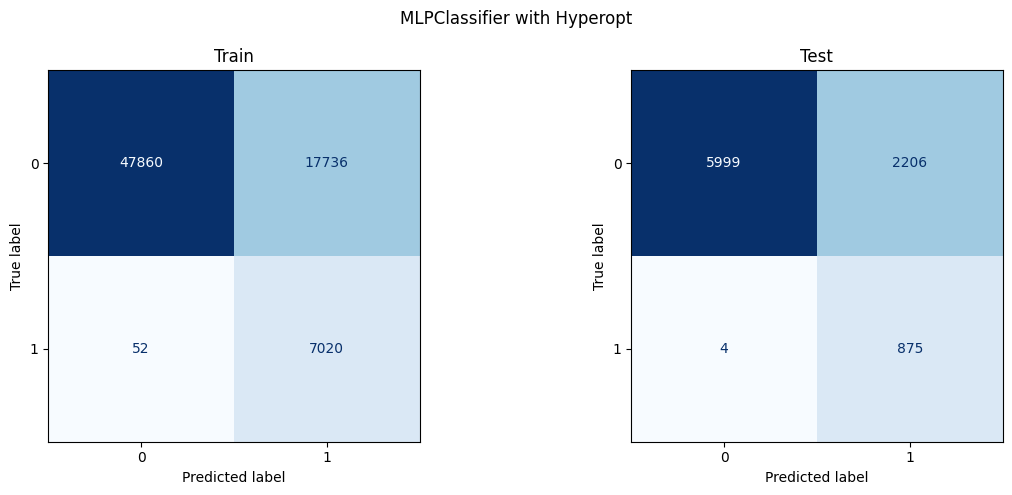

In [21]:
best_model = best_models_classifier_hyperopt["adam"]
make_graphic(best_model, "MLPClassifier with Hyperopt")

In [22]:
print(f"Архитектура сети: {best_model.hidden_layer_sizes}")

print(f"Количество слоев: {best_model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(3, 100), (100, 50), (50, 1)]



* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 100 нейронов.
* **Второй скрытый слой**: 50 нейронов.
* **Выходной слой**: 1 нейрон.


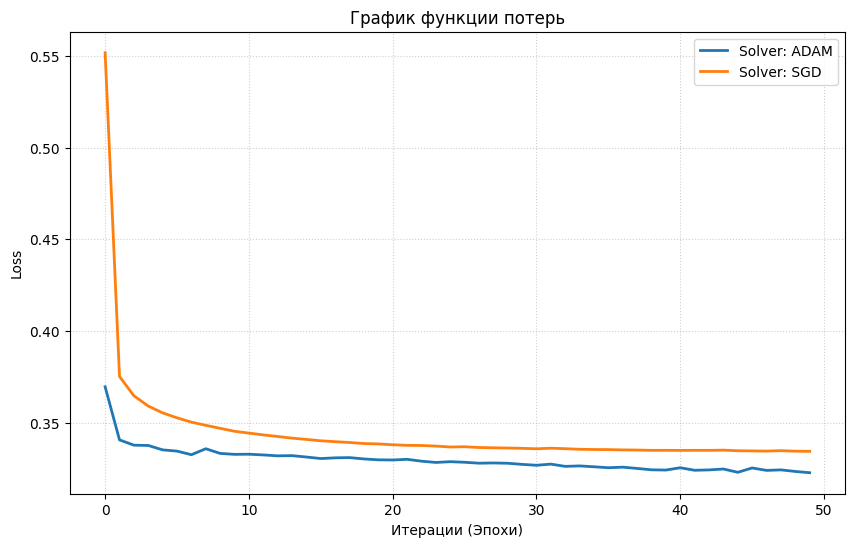

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for solver_name in ['adam', 'sgd']:
    model = best_models_classifier_optuna[solver_name]
    plt.plot(model.loss_curve_, label=f'Solver: {solver_name.upper()}', lw=2)

plt.title('График функции потерь')
plt.xlabel('Итерации (Эпохи)')
plt.ylabel('Loss')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Из графика видно, что у оптимизатора Adam скорость минимизации выше.

## Keras

In [6]:
import keras
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):
    train_pred = (model.predict(X_train) > 0.5).astype("int32")
    test_pred = (model.predict(X_test) > 0.5).astype("int32")

    new_row = {
        'Classifier': name,
        'Search strategy': search_name,
        'Train_F1': round(f1_score(y_train, train_pred), 2),
        'Train_Accuracy': round(accuracy_score(y_train, train_pred), 4),
        'Train_Precision': round(precision_score(y_train, train_pred), 4),
        'Train_Recall': round(recall_score(y_train, train_pred), 4),
        'Test_F1': round(f1_score(y_test, test_pred), 2),
        'Test_Accuracy': round(accuracy_score(y_test, test_pred), 4),
        'Test_Precision': round(precision_score(y_test, test_pred), 4),
        'Test_Recall': round(recall_score(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

In [29]:
def make_graphic_keras(model, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))


    y_train_pred = (model.predict(X_train) > 0.5).astype("int32")
    y_test_pred = (model.predict(X_test) > 0.5).astype("int32")


    cm_train = confusion_matrix(y_train, y_train_pred)
    disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
    disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title("Train")

    cm_test = confusion_matrix(y_test, y_test_pred)
    disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test)
    disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
    axes[1].set_title("Test")

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

In [29]:
solvers = ['adam', 'sgd', 'rmsprop']
best_models_keras_optuna = {}
keras_optuna_history = {}

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}


for current_solver in solvers:

    def objective(trial):
        n_layers = trial.suggest_int("n_layers", 1, 5)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
        activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu", "sigmoid"])
        batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        scores = []

        for train_idx, val_idx in kf.split(X_train_res):
            X_t, X_v = X_train_res[train_idx], X_train_res[val_idx]
            y_t, y_v = y_train_res.iloc[train_idx], y_train_res.iloc[val_idx]

            model = keras.Sequential()
            model.add(layers.Input(shape=(X_t.shape[1],)))

            for i in range(n_layers):
                num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
                model.add(layers.Dense(num_hidden, activation=activation))
                dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
                model.add(layers.Dropout(dropout_rate))

            model.add(layers.Dense(1, activation="sigmoid"))

            optimizer = optimizers_dict[current_solver](learning_rate=learning_rate)
            model.compile(
                optimizer=optimizer,
                loss="binary_crossentropy",
                metrics=["accuracy"]
            )

            early_stop = keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            )

            model.fit(
                X_t, y_t,
                validation_data=(X_v, y_v),
                epochs=15,
                batch_size=batch_size,
                callbacks=[early_stop],
                verbose=2
            )

            y_pred_probs = model.predict(X_v, verbose=0)
            y_pred = (y_pred_probs > 0.5).astype("int32")
            score = f1_score(y_v, y_pred)
            scores.append(score)

        return np.mean(scores)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=5)

    print(f"Лучшие параметры для {current_solver}: {study.best_params}")

    bp = study.best_params
    final_model = keras.Sequential()
    final_model.add(layers.Input(shape=(X_train_res.shape[1],)))

    for i in range(bp["n_layers"]):
        final_model.add(layers.Dense(bp[f"n_units_l{i}"], activation=bp["activation"]))
        final_model.add(layers.Dropout(bp[f"dropout_l{i}"]))

    final_model.add(layers.Dense(1, activation="sigmoid"))

    final_optimizer = optimizers_dict[current_solver](learning_rate=bp["learning_rate"])
    final_model.compile(
        optimizer=final_optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    final_early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    final_history = final_model.fit(
        X_train_res, y_train_res,
        validation_split=0.2,
        epochs=15,
        batch_size=bp["batch_size"],
        callbacks=[final_early_stop],
        verbose=0
    )

    best_models_keras_optuna[current_solver] = final_model
    keras_optuna_history[current_solver] = final_history

    model_name = f"Keras MLP ({current_solver})"
    input_into_table_keras(model_name, "Optuna", final_model, X_train, y_train, X_test, y_test, final_history)
table

Epoch 1/15
152/152 - 1s - 6ms/step - accuracy: 0.7593 - loss: 0.5069 - val_accuracy: 0.8493 - val_loss: 0.3878
Epoch 2/15
152/152 - 0s - 1ms/step - accuracy: 0.8210 - loss: 0.4149 - val_accuracy: 0.8487 - val_loss: 0.3773
Epoch 3/15
152/152 - 0s - 2ms/step - accuracy: 0.8274 - loss: 0.4060 - val_accuracy: 0.8510 - val_loss: 0.3698
Epoch 4/15
152/152 - 0s - 2ms/step - accuracy: 0.8254 - loss: 0.4011 - val_accuracy: 0.8489 - val_loss: 0.3635
Epoch 5/15
152/152 - 0s - 2ms/step - accuracy: 0.8287 - loss: 0.3946 - val_accuracy: 0.8498 - val_loss: 0.3580
Epoch 6/15
152/152 - 0s - 2ms/step - accuracy: 0.8330 - loss: 0.3896 - val_accuracy: 0.8498 - val_loss: 0.3529
Epoch 7/15
152/152 - 0s - 2ms/step - accuracy: 0.8326 - loss: 0.3841 - val_accuracy: 0.8555 - val_loss: 0.3483
Epoch 8/15
152/152 - 0s - 1ms/step - accuracy: 0.8372 - loss: 0.3770 - val_accuracy: 0.8591 - val_loss: 0.3443
Epoch 9/15
152/152 - 0s - 1ms/step - accuracy: 0.8363 - loss: 0.3745 - val_accuracy: 0.8471 - val_loss: 0.3434
E

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs
6,MLPClassifier (adam),Hyperopt,0.44,0.7552,0.2836,0.9954,0.44,0.7567,0.2840,0.9954,50,adam
7,MLPClassifier (sgd),Hyperopt,0.44,0.7566,0.2835,0.9909,0.44,0.7589,0.2853,0.9909,50,sgd
8,MLPClassifier (lbfgs),Hyperopt,0.44,0.7559,0.2836,0.9920,0.44,0.7589,0.2854,0.9920,50,lbfgs
9,Keras MLP (adam),Optuna,0.44,0.7604,0.2866,0.9822,0.45,0.7637,0.2894,0.9909,15,Adam


В модели Keras лучший результат у метрики recall равен 0.9966 у RMSprop.

In [31]:
model = best_models_keras_optuna['rmsprop']
model.summary()

Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_240 (Dense)               │ (None, 134)            │           536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_175 (Dropout)           │ (None, 134)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_241 (Dense)               │ (None, 206)            │        27,810 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_176 (Dropout)           │ (None, 206)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 51)             │        10,557 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_177 (Dropout)           │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 29)             │         1,508 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_178 (Dropout)           │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_244 (Dense)               │ (None, 107)            │         3,210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_179 (Dropout)           │ (None, 107)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_245 (Dense)               │ (None, 1)              │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,460 (341.64 KB)

 Trainable params: 43,729 (170.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,731 (170.83 KB)

* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 134 нейрона.
* **Второй скрытый слой**: 206 нейронов.
* **Третий скрытый слой**: 51 нейрон.
* **Четвертый скрытый слой**: 29 нейронов.
* **Пятый скрытый слой**: 107 нейронов.
* **Выходной слой**: 1 нейрон.

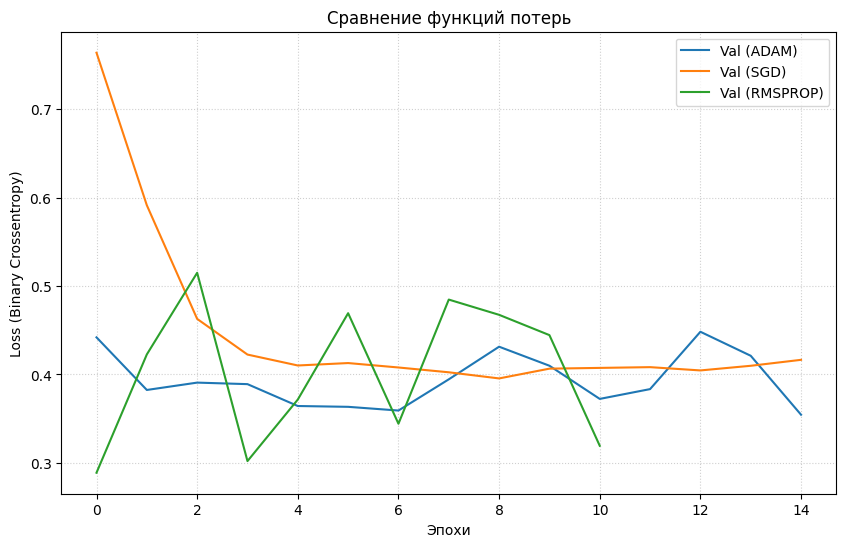

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for solver_name, history_obj in keras_optuna_history.items():

    metrics = history_obj.history

    plt.plot(metrics['val_loss'], label=f'Val ({solver_name.upper()})', lw=1.5)

plt.title('Сравнение функций потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss (Binary Crossentropy)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()


Заметим, что наименьшее значение функции потерь у оптимизатора Adam. Стоит отметить, что для оптимизатора RmsProp функция потерь представляет собой ломаную - требуется большее количество эпох для настройки этого оптимизатора.

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 675us/step


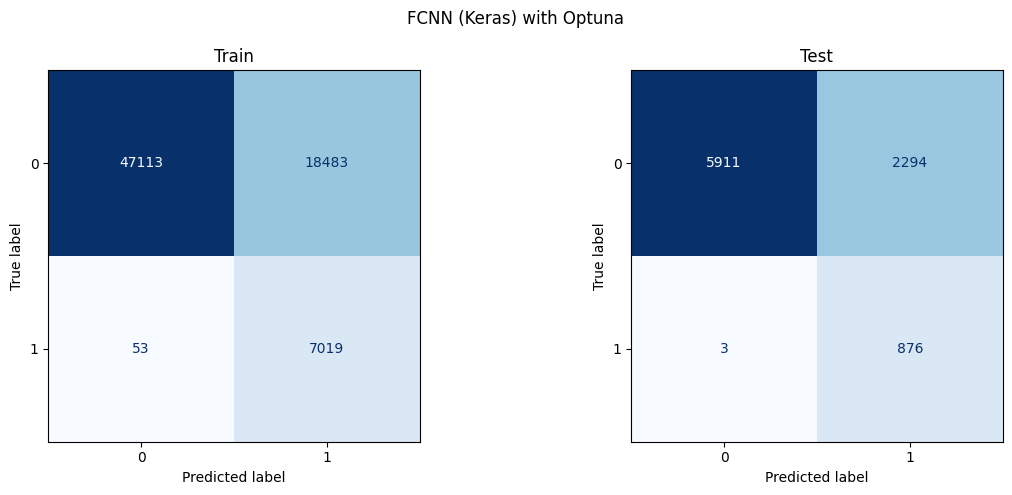

In [34]:
make_graphic_keras(model, "FCNN (Keras) with Optuna")

Заметим, что эта модель минизирует количество ошибок второго рода (то есть ложно - отрицательные срабатывания).

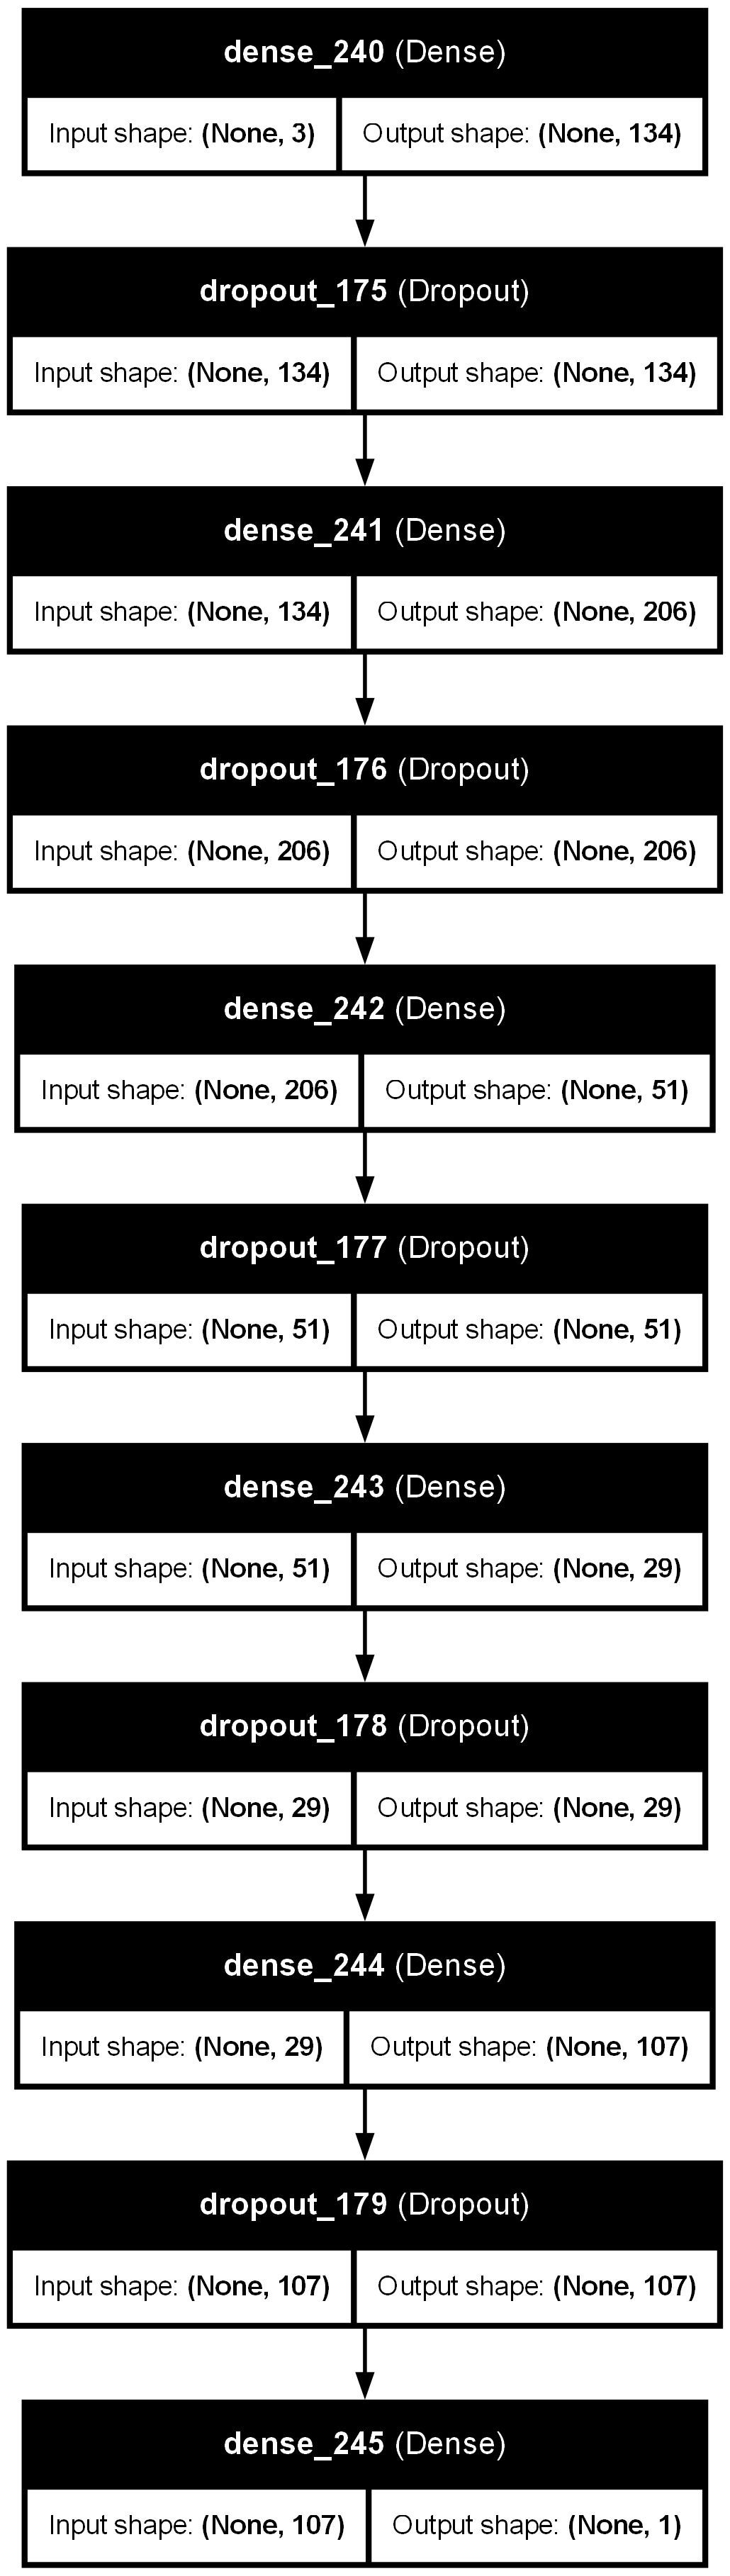

In [37]:
from keras.src.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    dpi=200
)

### KerasTuner

In [39]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

solvers = ['adam', 'sgd', 'rmsprop']
best_models_keras_tuner = {}
keras_tuner_history = {}

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

for current_solver in solvers:

    def build_model(hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(X_train_res.shape[1],)))

        activation_choice = hp.Choice("activation", ["relu", "tanh", "elu", "sigmoid"])

        for i in range(hp.Int("n_layers", 1, 5)):
            model.add(layers.Dense(
                units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
                activation=activation_choice
            ))
            if hp.Boolean("dropout"):
                model.add(layers.Dropout(0.2))

        model.add(layers.Dense(1, activation="sigmoid"))

        lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
        optimizer = optimizers_dict[current_solver](learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )
        return model

    tuner = kt.RandomSearch(
        build_model,
        objective="val_accuracy",
        max_trials=5,
        executions_per_trial=1,
        directory="keras_tuner_classification",
        project_name=f"fcnn_tuning_{current_solver}",
        overwrite=True
    )

    tuner.search(
        X_train_res, y_train_res,
        epochs=15,
        validation_split=0.2,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)],
        verbose=0
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"Лучшие параметры для {current_solver}: {best_hp.values}")

    final_model = tuner.get_best_models(num_models=1)[0]

    history = final_model.fit(
        X_train_res, y_train_res,
        validation_split=0.2,
        epochs=15,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )

    best_models_keras_tuner[current_solver] = final_model
    keras_tuner_history[current_solver] = history

    model_name = f"Keras MLP ({current_solver})"
    input_into_table_keras(model_name, "KerasTuner", final_model, X_train, y_train, X_test, y_test, history)
table

Лучшие параметры для adam: {'activation': 'elu', 'n_layers': 4, 'units_0': 416, 'dropout': True, 'lr': 0.004008276646393039, 'units_1': 32, 'units_2': 384, 'units_3': 352, 'units_4': 192}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container_1': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserW

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 535us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step
Лучшие параметры для sgd: {'activation': 'elu', 'n_layers': 3, 'units_0': 448, 'dropout': False, 'lr': 0.0032683059650986204, 'units_1': 480, 'units_2': 96, 'units_3': 64}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container_1': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserW

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 546us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
Лучшие параметры для rmsprop: {'activation': 'elu', 'n_layers': 4, 'units_0': 448, 'dropout': False, 'lr': 0.00966955488917958, 'units_1': 32, 'units_2': 32, 'units_3': 32}


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserWarning: Skipping nested container at 'layers/dense/variable_serialization_spec/container_1': no matching group found in the saved file. This usually means the file was saved with a Keras version that did not serialize sublayers nested inside containers. Affected layers will retain their freshly-initialized weights.
  _load_container_state(
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:840: UserW

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 563us/step


,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs
6,MLPClassifier (adam),Hyperopt,0.44,0.7552,0.2836,0.9954,0.44,0.7567,0.2840,0.9954,50,adam
7,MLPClassifier (sgd),Hyperopt,0.44,0.7566,0.2835,0.9909,0.44,0.7589,0.2853,0.9909,50,sgd
8,MLPClassifier (lbfgs),Hyperopt,0.44,0.7559,0.2836,0.9920,0.44,0.7589,0.2854,0.9920,50,lbfgs
9,Keras MLP (adam),Optuna,0.44,0.7604,0.2866,0.9822,0.45,0.7637,0.2894,0.9909,15,Adam


Для KerasTuner результаты recall тоже получились достаточно высокими - при применении оптимизатора RMSprop recall = 0.9954.

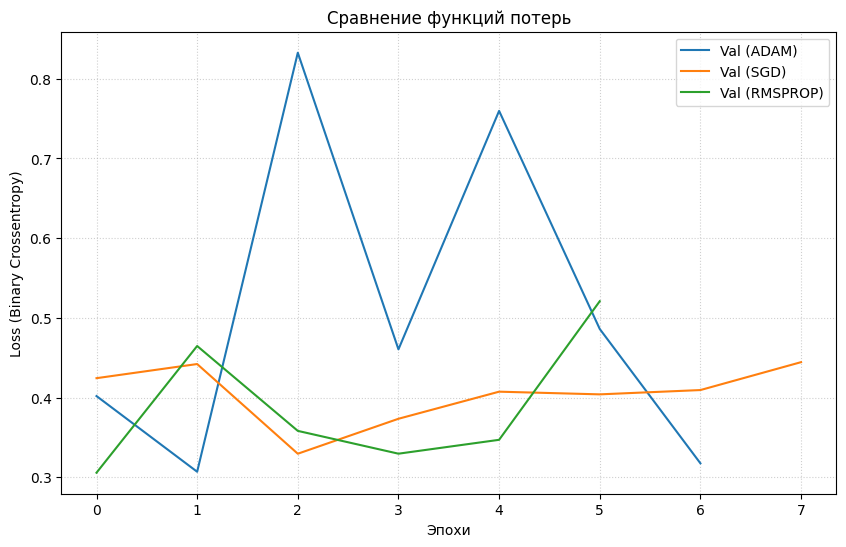

In [40]:
plt.figure(figsize=(10, 6))

for solver_name, history_obj in keras_tuner_history.items():

    metrics = history_obj.history

    plt.plot(metrics['val_loss'], label=f'Val ({solver_name.upper()})', lw=1.5)

plt.title('Сравнение функций потерь')
plt.xlabel('Эпохи')
plt.ylabel('Loss (Binary Crossentropy)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()


У оптимизатора Adam и RmsProp график функции потерь представляет собой ломаную - это говорит о том, что для применения алгоритма стоит добавить большее число эпох. При этом за текущее число эпох у Adam наименьшая величина ошибки.

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 463us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step


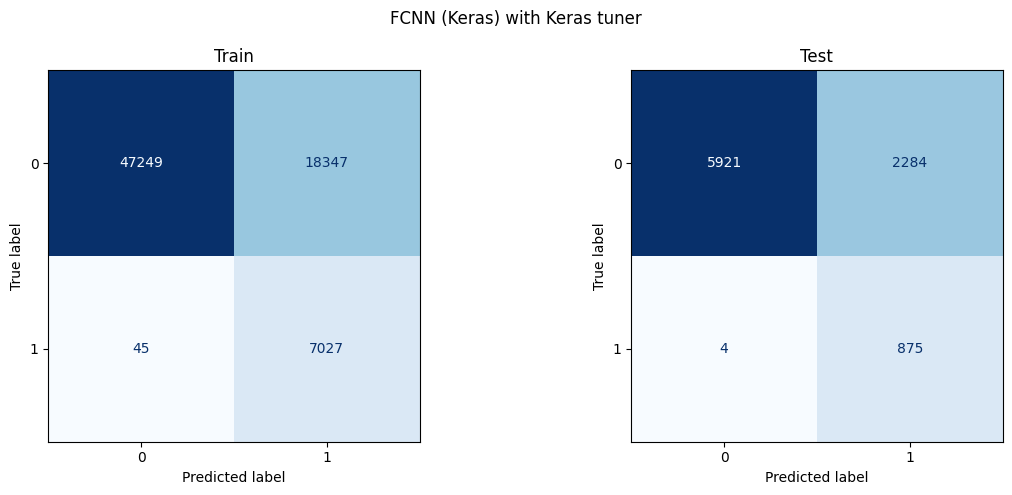

In [41]:
best_model = best_models_keras_tuner['rmsprop']
make_graphic_keras(best_model, "FCNN (Keras) with Keras tuner")

In [42]:
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 448)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        14,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,612 (143.02 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,307 (71.52 KB)

* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 448 нейронов.
* **Второй скрытый слой**: 32 нейрона.
* **Третий скрытый слой**: 32 нейрона.
* **Четвертый скрытый слой**: 32 нейрона.
* **Выходной слой**: 1 нейрон.


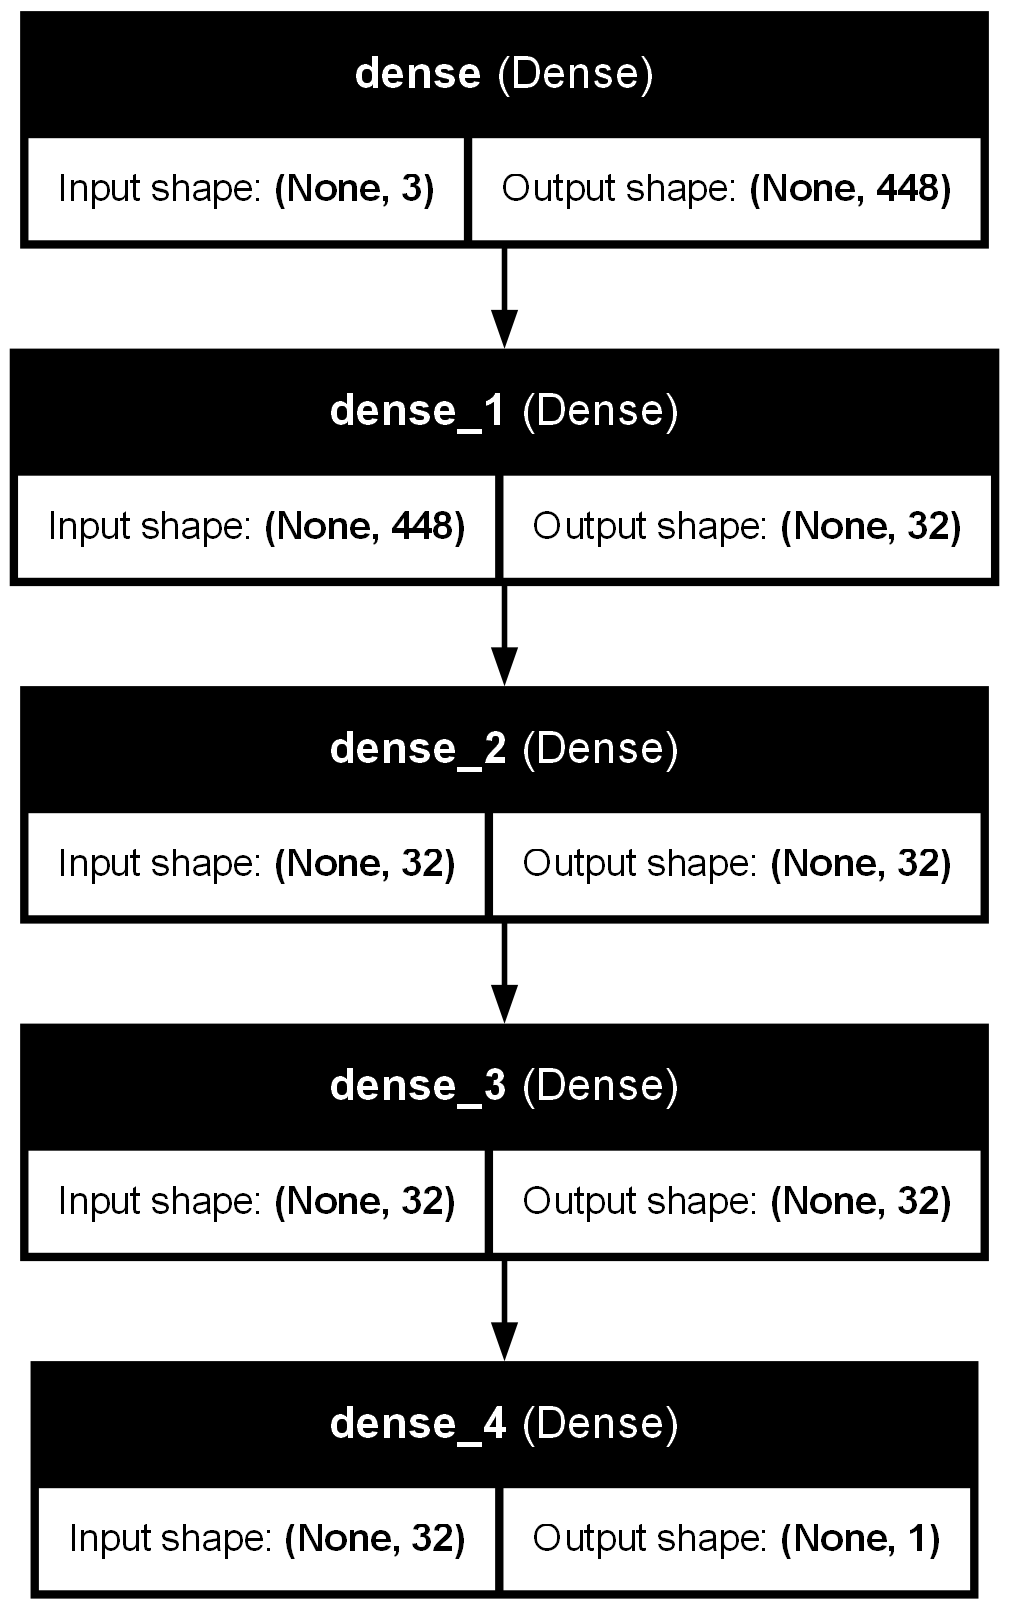

In [43]:
plot_model(
    best_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

### RayTune

In [12]:
from ray import tune
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

def get_tune_model(opt):

    def train_model_ray(config):
        kf = KFold(n_splits=3, shuffle=True, random_state=42)
        fold_results = []

        for train_idx, val_idx in kf.split(X_train):
            X_t, X_v = X_train[train_idx], X_train[val_idx]
            y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model = Sequential()
            model.add(layers.Input(shape=(X_t.shape[1],)))

            for i in range(config["n_layers"]):
                model.add(layers.Dense(units=config[f"units_{i}"], activation=config["activation"]))
                model.add(layers.Dropout(config["dropout_rate"]))

            model.add(layers.Dense(1, activation="sigmoid"))

            optimizer = opt(learning_rate=config["lr"])
            model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

            model.fit(X_t, y_t, epochs=20, batch_size=32, validation_data=(X_v, y_v), verbose=0)

            y_pred = (model.predict(X_v, verbose=0) > 0.5).astype("int32")
            fold_results.append(f1_score(y_v, y_pred))

        tune.report({"mean_f1": float(np.mean(fold_results))})

    search_space = {
        "n_layers": tune.randint(1, 4),
        "activation": tune.choice(["relu", "tanh", "sigmoid"]),
        "dropout_rate": tune.uniform(0.0, 0.3),
        "lr": tune.loguniform(1e-4, 1e-2),
    }

    for i in range(4):
        search_space[f"units_{i}"] = tune.qrandint(32, 256, 32)

    tuner = tune.Tuner(
        train_model_ray,
        param_space=search_space,
        tune_config=tune.TuneConfig(
            metric="mean_f1",
            mode="max",
            num_samples=5
        )
    )

    results = tuner.fit()
    print("Лучшие параметры:", results.get_best_result().config)
    config = results.get_best_result().config
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for i in range(config["n_layers"]):
        model.add(layers.Dense(
            units=config[f"units_{i}"],
            activation=config["activation"]
        ))
        model.add(layers.Dropout(config["dropout_rate"]))

    model.add(layers.Dense(1, activation="sigmoid"))

    optimizer = opt(learning_rate=config["lr"])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

    history = model.fit(
        X_train,
        y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=2
    )

    input_into_table_keras(
        name="FCNN (Keras)",
        search_name="Ray Tune",
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        history=history
    )

    return history, model

adam_history, adam_model = get_tune_model(keras.optimizers.Adam)

2026-05-16 09:53:48,490	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_09-53-48\train_model_ray_2026-05-16_09-53-48\driver_artifacts\train_model_ray_d80dd_00000_0_activation=sigmoid,dropout_rate=0.1216,lr=0.0002,n_layers=3,units_0=192,units_1=128,units_2=96,units_2026-05-16_09-53-48
2026-05-16 09:53:48,515	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_09-53-48\train_model_ray_2026-05-16_09-53-48\driver_artifacts\train_model_ray_d80dd_00000_0_activation=sigmoid,dropout_rate=0.1216,lr=0.0002,n_layers=3,units_0=192,units_1=128,units_2=96,units_2026-05-16_09-53-48
2026-05-16 09:

(pid=17204) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=17204) I0000 00:00:1778903638.717227    5780 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
(raylet) Stack (most recent call first): [repeated 4x across cluster]
(raylet)   File "C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\ray\_private\worker.py", line 628 in job_logging_config [repeated 4x across cluster]
(raylet)   File "C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\ray\_private\worker.py", line 2801 in disconnect [repeated 4x across cluster]
(raylet)   File "C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\ray\_private\worker.py", line 2132 in shutdown [repeated 4x across cluster]
(raylet)   File "C:\Users\79585\Desktop\practicum--4-

Лучшие параметры: {'n_layers': 2, 'activation': 'relu', 'dropout_rate': 0.0026852148603093485, 'lr': 0.00043377537137603297, 'units_0': 160, 'units_1': 160, 'units_2': 192, 'units_3': 96}
Epoch 1/50
2271/2271 - 3s - 1ms/step - accuracy: 0.9016 - loss: 0.2089 - val_accuracy: 0.9040 - val_loss: 0.2040
Epoch 2/50
2271/2271 - 2s - 1000us/step - accuracy: 0.9032 - loss: 0.2032 - val_accuracy: 0.9037 - val_loss: 0.2024
Epoch 3/50
2271/2271 - 2s - 1ms/step - accuracy: 0.9039 - loss: 0.2019 - val_accuracy: 0.9021 - val_loss: 0.2020
Epoch 4/50
2271/2271 - 2s - 1ms/step - accuracy: 0.9047 - loss: 0.2009 - val_accuracy: 0.9038 - val_loss: 0.2008
Epoch 5/50
2271/2271 - 2s - 954us/step - accuracy: 0.9051 - loss: 0.1999 - val_accuracy: 0.9062 - val_loss: 0.1991
Epoch 6/50
2271/2271 - 2s - 964us/step - accuracy: 0.9061 - loss: 0.1990 - val_accuracy: 0.8952 - val_loss: 0.2063
Epoch 7/50
2271/2271 - 2s - 996us/step - accuracy: 0.9076 - loss: 0.1981 - val_accuracy: 0.9085 - val_loss: 0.1979
Epoch 8/50
2

In [5]:
with open('table.pkl', 'rb') as f:
    table = pickle.load(f)

In [13]:
s_history, s_model = get_tune_model(keras.optimizers.SGD)

2026-05-16 10:03:55,479	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-03-55\train_model_ray_2026-05-16_10-03-55\driver_artifacts\train_model_ray_41de1_00000_0_activation=tanh,dropout_rate=0.2336,lr=0.0012,n_layers=3,units_0=64,units_1=160,units_2=192,units_3=_2026-05-16_10-03-55
2026-05-16 10:03:55,496	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-03-55\train_model_ray_2026-05-16_10-03-55\driver_artifacts\train_model_ray_41de1_00000_0_activation=tanh,dropout_rate=0.2336,lr=0.0012,n_layers=3,units_0=64,units_1=160,units_2=192,units_3=_2026-05-16_10-03-55
2026-05-16 10:

(pid=16348) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=16348) I0000 00:00:1778904241.258763   15476 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 10:04:07,122	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-03-55\train_model_ray_2026-05-16_10-03-55\driver_artifacts\train_model_ray_41de1_00002_2_activation=tanh,dropout_rate=0.1086,lr=0.0068,n_layers=1,units_0=32,units_1=224,units_2=192,units_3=_2026-05-16_10-03-55
2026-05-16 10:04:07,125	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. C

Лучшие параметры: {'n_layers': 1, 'activation': 'tanh', 'dropout_rate': 0.10862004712339718, 'lr': 0.0067769885068939655, 'units_0': 32, 'units_1': 224, 'units_2': 192, 'units_3': 64}
Epoch 1/50
2271/2271 - 2s - 893us/step - accuracy: 0.8952 - loss: 0.2443 - val_accuracy: 0.9021 - val_loss: 0.2196
Epoch 2/50
2271/2271 - 2s - 710us/step - accuracy: 0.8988 - loss: 0.2222 - val_accuracy: 0.9021 - val_loss: 0.2148
Epoch 3/50
2271/2271 - 2s - 742us/step - accuracy: 0.9000 - loss: 0.2191 - val_accuracy: 0.9021 - val_loss: 0.2125
Epoch 4/50
2271/2271 - 2s - 704us/step - accuracy: 0.9003 - loss: 0.2175 - val_accuracy: 0.9021 - val_loss: 0.2117
Epoch 5/50
2271/2271 - 2s - 721us/step - accuracy: 0.9004 - loss: 0.2158 - val_accuracy: 0.9021 - val_loss: 0.2101
Epoch 6/50
2271/2271 - 2s - 729us/step - accuracy: 0.9007 - loss: 0.2147 - val_accuracy: 0.9021 - val_loss: 0.2095
Epoch 7/50
2271/2271 - 2s - 711us/step - accuracy: 0.9016 - loss: 0.2139 - val_accuracy: 0.9022 - val_loss: 0.2090
Epoch 8/50


C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\79585\Desktop\practicum--4-term\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [16]:
r_history, r_model = get_tune_model(keras.optimizers.RMSprop)

2026-05-16 10:17:38,223	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-17-38\train_model_ray_2026-05-16_10-17-38\driver_artifacts\train_model_ray_2c453_00000_0_activation=tanh,dropout_rate=0.2814,lr=0.0031,n_layers=3,units_0=128,units_1=96,units_2=64,units_3=1_2026-05-16_10-17-38
2026-05-16 10:17:38,240	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-17-38\train_model_ray_2026-05-16_10-17-38\driver_artifacts\train_model_ray_2c453_00000_0_activation=tanh,dropout_rate=0.2814,lr=0.0031,n_layers=3,units_0=128,units_1=96,units_2=64,units_3=1_2026-05-16_10-17-38
2026-05-16 10:

(pid=14256) WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
(pid=14256) I0000 00:00:1778905063.131297   16432 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-16 10:17:46,801	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-16_09-48-09_747545_17680\artifacts\2026-05-16_10-17-38\train_model_ray_2026-05-16_10-17-38\driver_artifacts\train_model_ray_2c453_00000_0_activation=tanh,dropout_rate=0.2814,lr=0.0031,n_layers=3,units_0=128,units_1=96,units_2=64,units_3=1_2026-05-16_10-17-38
2026-05-16 10:17:46,817	WARNING trial.py:602 -- The path to the trial log directory is too long (max length: 260. C

Лучшие параметры: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.12534088695483073, 'lr': 0.0006025535359967162, 'units_0': 224, 'units_1': 192, 'units_2': 128, 'units_3': 128}
Epoch 1/50
2271/2271 - 2s - 1ms/step - accuracy: 0.9014 - loss: 0.2103 - val_accuracy: 0.9021 - val_loss: 0.2042
Epoch 2/50
2271/2271 - 2s - 792us/step - accuracy: 0.9027 - loss: 0.2047 - val_accuracy: 0.9027 - val_loss: 0.2038
Epoch 3/50
2271/2271 - 2s - 781us/step - accuracy: 0.9037 - loss: 0.2036 - val_accuracy: 0.9038 - val_loss: 0.2035
Epoch 4/50
2271/2271 - 2s - 770us/step - accuracy: 0.9037 - loss: 0.2028 - val_accuracy: 0.9021 - val_loss: 0.2035
Epoch 5/50
2271/2271 - 2s - 777us/step - accuracy: 0.9042 - loss: 0.2023 - val_accuracy: 0.9054 - val_loss: 0.2029
Epoch 6/50
2271/2271 - 2s - 788us/step - accuracy: 0.9043 - loss: 0.2018 - val_accuracy: 0.8991 - val_loss: 0.2058
Epoch 7/50
2271/2271 - 2s - 777us/step - accuracy: 0.9044 - loss: 0.2019 - val_accuracy: 0.9061 - val_loss: 0.2038
Epoch 8/50


In [19]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs
6,MLPClassifier (adam),Hyperopt,0.44,0.7552,0.2836,0.9954,0.44,0.7567,0.2840,0.9954,50,adam
7,MLPClassifier (sgd),Hyperopt,0.44,0.7566,0.2835,0.9909,0.44,0.7589,0.2853,0.9909,50,sgd
8,MLPClassifier (lbfgs),Hyperopt,0.44,0.7559,0.2836,0.9920,0.44,0.7589,0.2854,0.9920,50,lbfgs
9,Keras MLP (adam),Optuna,0.44,0.7604,0.2866,0.9822,0.45,0.7637,0.2894,0.9909,15,Adam


Лучшей моделью, полученной с RayTune, оказалась модель, полученная при помощи оптимизатора Adam (f1 = 0.32, recall = 0.2162, precision = 0.6013). Модель, построенная на основе SGD, показала худшие результаты (f1 = 0).
При этом модель, полученная при помощи оптимизатора RMSpropr показала самый высокий результат precision (0.7083).

Рассмотрим последнюю модель.

In [20]:
model = r_model
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 224)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244 (8.77 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,123 (4.39 KB)

* **Входной слой**: 3 нейрона.
* **Первый скрытый слой**: 224 нейрона.
* **Выходной слой**: 1 нейрон.

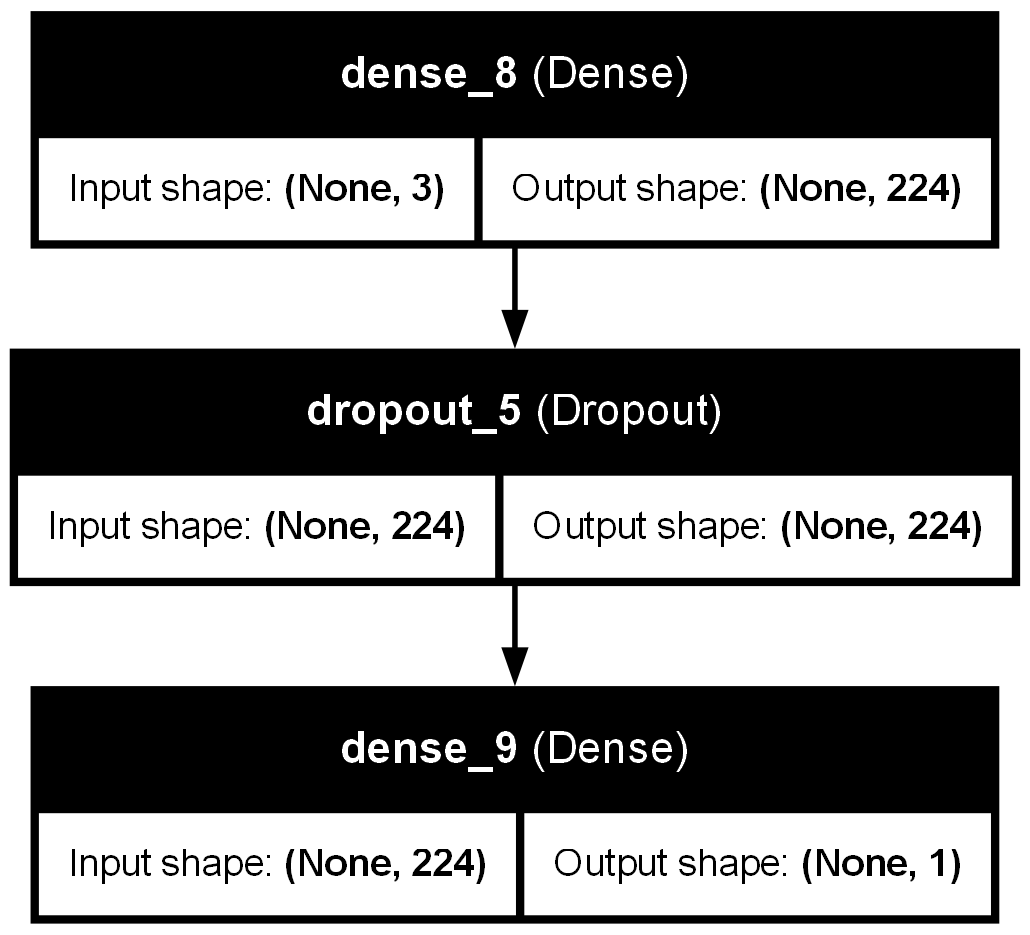

In [37]:
plot_model(
    model,
    show_shapes=True,
    show_layer_names=True,
    dpi=200
)

Text(0, 0.5, 'Loss')

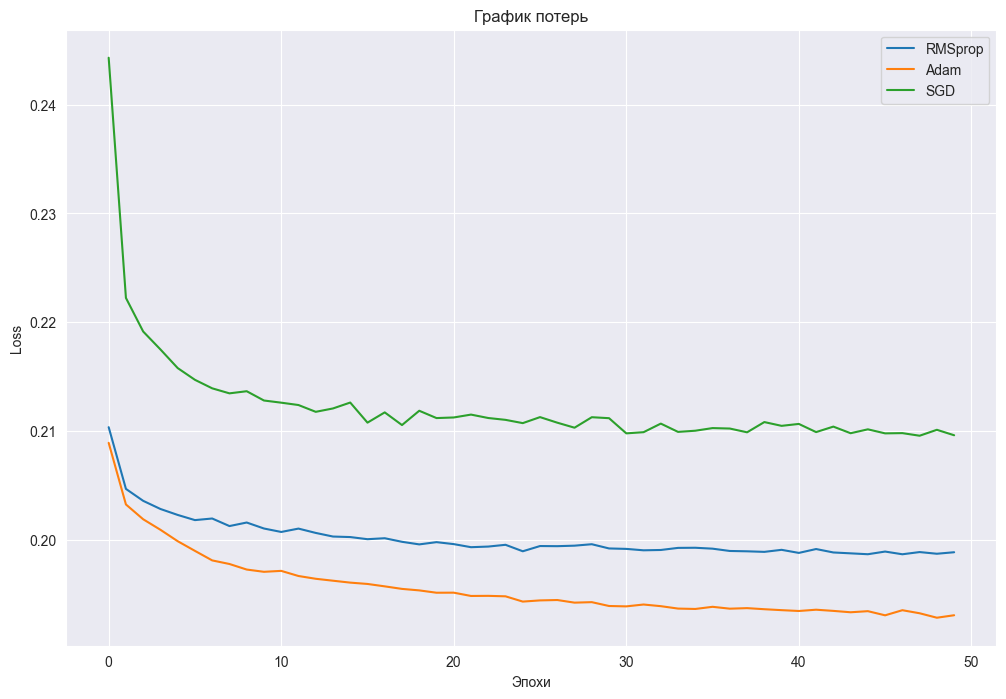

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.plot(r_history.history['loss'], label="RMSprop")
plt.plot(adam_history.history['loss'], label="Adam")
plt.plot(s_history.history['loss'], label="SGD")
plt.title("График потерь")
plt.legend()
plt.xlabel("Эпохи")
plt.ylabel("Loss")

По графику видно, что наименьшую ошибку имеет оптимизатор Adam.

2271/2271 ━━━━━━━━━━━━━━━━━━━━ 1s 393us/step
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 454us/step


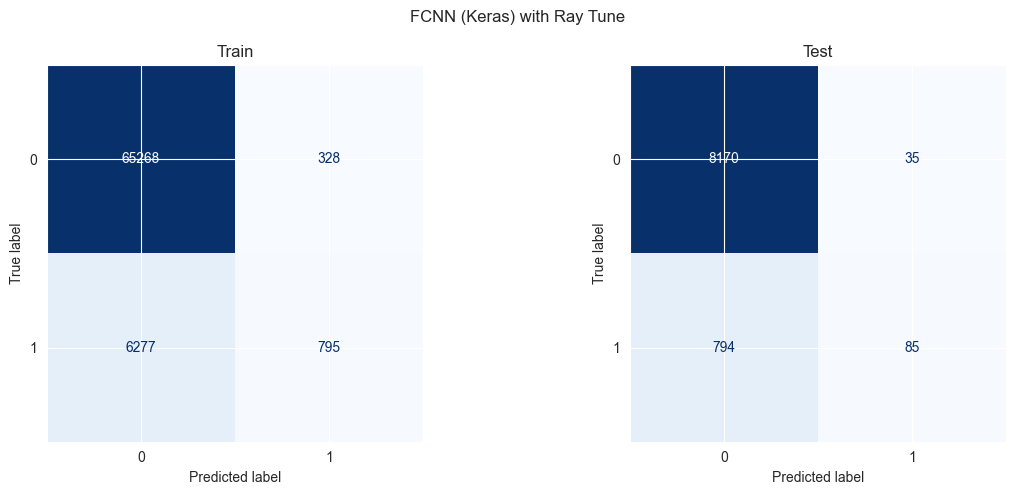

In [34]:
make_graphic_keras(model, "FCNN (Keras) with Ray Tune")

Можно заметить, что минимизируется ошибка первого рода (то есть ложно положительные срабатывания), что подтверждается высоким precision.

## Вывод

In [35]:
table

,Classifier,Search strategy,Train_F1,Train_Accuracy,Train_Precision,Train_Recall,Test_F1,Test_Accuracy,Test_Precision,Test_Recall,Epochs,Solver
0,MLPClassifier (adam),Optuna,0.44,0.7552,0.2835,0.9966,0.44,0.7577,0.2850,0.9966,50,adam
1,MLPClassifier (sgd),Optuna,0.44,0.7572,0.2836,0.9863,0.44,0.7600,0.2857,0.9863,50,sgd
2,MLPClassifier (lbfgs),Optuna,0.44,0.7565,0.2839,0.9920,0.44,0.7597,0.2861,0.9920,50,lbfgs
3,MLPClassifier (adam),RandomizedSearch,0.44,0.7548,0.2833,0.9966,0.44,0.7573,0.2846,0.9966,50,adam
4,MLPClassifier (sgd),RandomizedSearch,0.44,0.7587,0.2846,0.9898,0.44,0.7609,0.2868,0.9898,50,sgd
5,MLPClassifier (lbfgs),RandomizedSearch,0.44,0.7552,0.2829,0.9920,0.44,0.7583,0.2849,0.9920,50,lbfgs
6,MLPClassifier (adam),Hyperopt,0.44,0.7552,0.2836,0.9954,0.44,0.7567,0.2840,0.9954,50,adam
7,MLPClassifier (sgd),Hyperopt,0.44,0.7566,0.2835,0.9909,0.44,0.7589,0.2853,0.9909,50,sgd
8,MLPClassifier (lbfgs),Hyperopt,0.44,0.7559,0.2836,0.9920,0.44,0.7589,0.2854,0.9920,50,lbfgs
9,Keras MLP (adam),Optuna,0.44,0.7604,0.2866,0.9822,0.45,0.7637,0.2894,0.9909,15,Adam


Прежде всего стоит отметить, что нейросетевой подход не достаточно подходит для этих данных, так как с его помощью были получены низкие метрики. Максимальным recall (0.9966) обладает модель MLPClassifier, построенная с помощью Optuna. Эта же модель имеет f1 = 0.44 и precision = 0.2850.

Стоит отметить, что нейросетевой подход хорошо подошел для датасета задачи классификации, так как практически все методы подбора гиперпараметров давали хорошие результаты с высоким показателем метрики полноты.

In [109]:
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv("datasets/neo.csv", index_col = 0)
X, y = data.drop("hazardous", axis=1), data["hazardous"]

pipeline = Pipeline([
    ('minmax', MinMaxScaler()),
    ('scaler', StandardScaler()),
    ('umap', UMAP(n_components=3, random_state=42)),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(50, 50),
        solver='adam',
        activation='relu',
        alpha=0.001408268688175312,
        learning_rate='constant',
        learning_rate_init=0.00037123954916206667,
        random_state=42,
    ))
])
pipeline.fit(X, y)

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Pipeline(steps=[('minmax', MinMaxScaler()), ('scaler', StandardScaler()),
                ('umap',
                 UMAP(n_components=3, n_jobs=1, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})),
                ('mlp',
                 MLPClassifier(alpha=0.001408268688175312,
                               hidden_layer_sizes=(50, 50),
                               learning_rate_init=0.00037123954916206667,
                               random_state=42))])

In [111]:
sample_data = single_object = {
    'est_diameter_min': [0.127],
    'est_diameter_max': [0.284],
    'relative_velocity': [52340.5],
    'miss_distance': [4500000.0],
    'absolute_magnitude': [21.5]}

sample_df = pd.DataFrame(single_object)

prediction = pipeline.predict(sample_df)
print(f"Результат предсказания: {prediction[0]}")

Результат предсказания: 0


Модель посчитала объект неопасным. 